In [6]:
# External Imports
import sys
from pathlib import Path
import torch
import torch.optim as optim
import torch.nn as nn

# Internal Imports
sys.path.insert(0, '../src')
from src.Dataset.mri_split import split_patients
from src.Dataset.data_loaders import get_dataloaders
from src.Dataset.cache import load_cache
from src.Model.train import fit
from src.Model.evaluation import test
from src.Model.Unet.Unet import UNetModel, DiceLoss
from src.Visualization.visualization import plot_loss_acc
from src.Model.persistance import save_weights, load_weights

In [ ]:
accepted_data = {}
rejected_data = {}
try:
    accepted_data = load_cache(Path("../data/processed/cache/accepted_data.json"), Path.cwd().parent)
    rejected_data = load_cache(Path("../data/processed/cache/rejected_data.json"), Path.cwd().parent)
except BaseException as e:
    print(e)

In [ ]:
SPLIT_SEED = 42
train_patients, val_patients, test_patients = split_patients(accepted_data, seed=SPLIT_SEED)

In [4]:
BATCH_SIZE = 32
train_dataloader, val_dataloader, test_dataloader = get_dataloaders(
    train_patients,
    val_patients,
    test_patients,
    batch_size=BATCH_SIZE,
    segmentation=True
)

C:\Users\pc\miniconda3\envs\BrainTumorMRIClassification\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [5]:
images, masks = next(iter(train_dataloader))

In [6]:
print(images.shape)
print(masks.shape)
print(masks.unique())
print(images.dtype)
print(masks.dtype)

torch.Size([32, 3, 224, 224])
torch.Size([32, 1, 224, 224])
tensor([0., 1.])
torch.float32
torch.float32


# CHECKPOINT

Next is writing the training loop

In [5]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(device)

model = UNetModel(in_channels = 3, out_channels = 1)
model = model.to(device)

loss_fn = DiceLoss()

OPTIMIZER = torch.optim.Adam(model.parameters(), lr=1e-4)
EPOCHS = 100
PATIENCE = 5
SEGMENTATION = True

cuda


In [8]:
history = fit(model, train_dataloader, val_dataloader, loss_fn, OPTIMIZER, device, EPOCHS, PATIENCE, SEGMENTATION)


Epoch   1/100 | Time: 0:00:48 | Patience: 0/5 | LR: 0.0001
  Train  — Loss: 0.9478  Dice: 0.1569
  Valid  — Loss: 0.9415  Dice: 0.2841

Epoch   2/100 | Time: 0:00:47 | Patience: 0/5 | LR: 0.0001
  Train  — Loss: 0.9316  Dice: 0.2659
  Valid  — Loss: 0.9432  Dice: 0.1271

Epoch   3/100 | Time: 0:00:47 | Patience: 1/5 | LR: 0.0001
  Train  — Loss: 0.9210  Dice: 0.2943
  Valid  — Loss: 0.9321  Dice: 0.2121

Epoch   4/100 | Time: 0:00:47 | Patience: 0/5 | LR: 0.0001
  Train  — Loss: 0.9062  Dice: 0.3495
  Valid  — Loss: 0.9249  Dice: 0.2013

Epoch   5/100 | Time: 0:00:47 | Patience: 0/5 | LR: 0.0001
  Train  — Loss: 0.8888  Dice: 0.3843
  Valid  — Loss: 0.8972  Dice: 0.3499

Epoch   6/100 | Time: 0:00:47 | Patience: 0/5 | LR: 0.0001
  Train  — Loss: 0.8600  Dice: 0.4778
  Valid  — Loss: 0.8773  Dice: 0.3918

Epoch   7/100 | Time: 0:00:46 | Patience: 0/5 | LR: 0.0001
  Train  — Loss: 0.8241  Dice: 0.5290
  Valid  — Loss: 0.8625  Dice: 0.4016

Epoch   8/100 | Time: 0:00:46 | Patience: 0/5 |

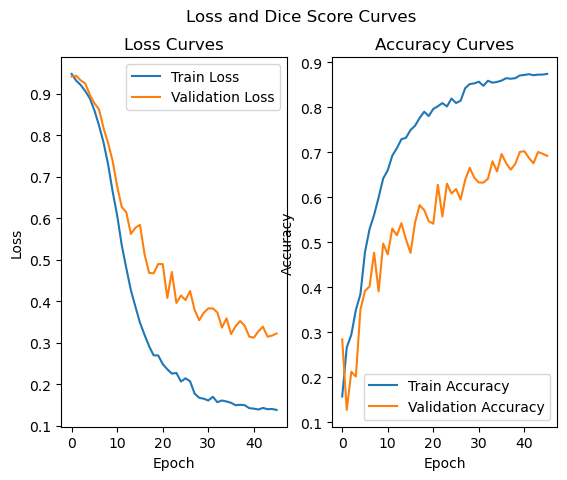

In [9]:
plot_loss_acc(history, "Loss and Dice Score Curves")

In [ ]:
save_weights("unet", model, Path("../models"))

In [7]:
load_weights(model, Path("../models/unet_2026-03-30_01h03-26s.pth"), device)
model.to(device)

UNetModel(
  (encoder1): Encoder(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout2d(p=0.0, inplace=False)
        (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (6): ReLU()
        (7): Dropout2d(p=0.0, inplace=False)
      )
    )
    (max_pool): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (encoder2): Encoder(
    (conv): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Dropout2d(p=0.0, inplace=False)
        (4):

In [8]:
test_dice_score = test(model, test_dataloader, device)
print(test_dice_score)

0.7281615659594536
